Data successfully anonymized and saved as productivity_data_features.csv!
--- Summary Statistics ---


,Sleep_Hours,Phone_Screen_Time_Hours,Study_Hours,Classes_Attended,Mood_Score_1_to_10,Productivity_Score_1_to_10
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,6.833333,6.778667,3.533333,2.600000,5.666667,5.466667
std,1.732144,1.570709,3.226379,2.261479,2.126925,2.474633
min,3.670000,4.180000,0.000000,0.000000,1.000000,1.000000
25%,5.750000,5.635000,0.000000,0.000000,5.000000,4.000000
50%,6.330000,6.700000,3.000000,3.000000,6.000000,6.000000
75%,7.585000,8.000000,6.500000,4.000000,7.000000,7.500000
max,10.330000,9.220000,8.000000,7.000000,9.000000,9.000000


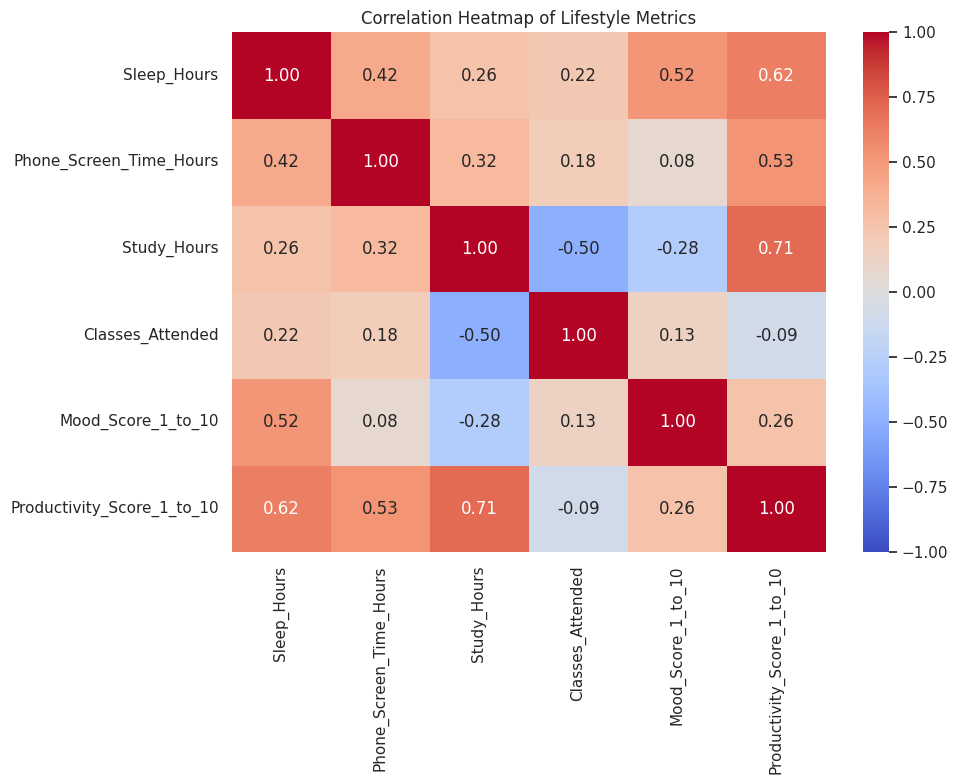

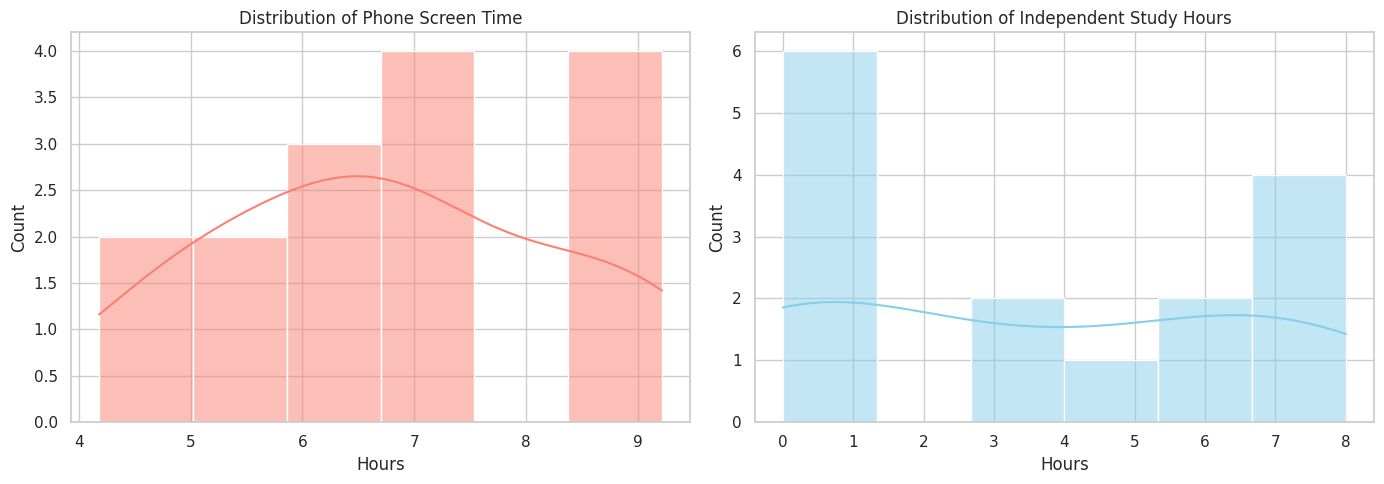

--- Hypothesis 1: Does longer sleep duration lead to higher productivity? ---
Pearson Correlation Coefficient: 0.624
P-value: 0.013
Conclusion: There is a statistically significant relationship between sleep and productivity.

-------------------------------------------------------------------

--- Hypothesis 2: Does increased phone usage negatively affect study time? ---
Pearson Correlation Coefficient: 0.315
P-value: 0.253
Conclusion: We fail to reject the null hypothesis. No statistically significant relationship was found with this current sample size.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Load dataset
df_raw = pd.read_csv('dsa210_collected_data.csv')

#Drop the date to anonymize
df_features = df_raw.drop(columns=['Date'])

#Save the safe dataset
df_features.to_csv('productivity_data_features.csv', index=False)
print("Data successfully anonymized and saved as productivity_data_features.csv!")

df_features.head()

#Load anonymized dataset
df = pd.read_csv('productivity_data_features.csv')

print("--- Summary Statistics ---")
display(df.describe())

sns.set_theme(style="whitegrid")




#Graph 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title("Correlation Heatmap of Lifestyle Metrics")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

#Graph 2: Distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Phone_Screen_Time_Hours'], bins=6, kde=True, ax=ax[0], color='salmon')
ax[0].set_title('Distribution of Phone Screen Time')
ax[0].set_xlabel('Hours')

sns.histplot(df['Study_Hours'], bins=6, kde=True, ax=ax[1], color='skyblue')
ax[1].set_title('Distribution of Independent Study Hours')
ax[1].set_xlabel('Hours')

plt.tight_layout()
plt.savefig("distributions.png")
plt.show()




print("--- Hypothesis 1: Does longer sleep duration lead to higher productivity? ---")
sleep_corr, sleep_p_value = stats.pearsonr(df['Sleep_Hours'], df['Productivity_Score_1_to_10'])
print(f"Pearson Correlation Coefficient: {sleep_corr:.3f}")
print(f"P-value: {sleep_p_value:.3f}")

if sleep_p_value < 0.05:
    print("Conclusion: There is a statistically significant relationship between sleep and productivity.")
else:
    print("Conclusion: We fail to reject the null hypothesis. The relationship is not statistically significant (which is expected with a small sample size of 15 days).")

print("\n-------------------------------------------------------------------\n")

print("--- Hypothesis 2: Does increased phone usage negatively affect study time? ---")
phone_corr, phone_p_value = stats.pearsonr(df['Phone_Screen_Time_Hours'], df['Study_Hours'])
print(f"Pearson Correlation Coefficient: {phone_corr:.3f}")
print(f"P-value: {phone_p_value:.3f}")

if phone_p_value < 0.05:
    print("Conclusion: There is a statistically significant relationship between phone screen time and study hours.")
else:
    print("Conclusion: We fail to reject the null hypothesis. No statistically significant relationship was found with this current sample size.")